# Live LeRobot facade over a second real dataset: RoboLab-EgoX

The [ABC-130k notebook](./abc130k_live_lerobot_facade_demo.ipynb) proved the
live LeRobot facade end to end, but ABC-130k has no success/failure label --
its "failure search" section had to fall back to a data-quality gate as an
honest proxy. This notebook uses
[Voxel51/RoboLab-EgoX](https://huggingface.co/datasets/Voxel51/RoboLab-EgoX)
(real, ungated, Apache-2.0 MCAP episodes of NVIDIA's RoboLab manipulation
benchmark) instead, which carries a **genuine ground-truth `success`/`failure`
label per episode** (632 successful / 3,368 failed across the full corpus) --
so this time the failure search is real, not a proxy.

Building this surfaced a real, previously-unknown bug: RoboLab-EgoX's
`/joint-positions` (13-length) and `/actions` (8-length) topics reuse the
exact same bare protobuf schema name `RobotState` that XDOF ABC-130k already
claimed for its own, unrelated 6-length arm-joint layout -- a genuine
cross-dataset schema-name collision. `extract.py` now disambiguates by real
field length rather than assuming a schema name is globally unique (see the
recorded decision for details).

Pipeline: **download -> ingest -> confirm the schema-collision fix -> explore
visually -> real success/failure search -> align -> live facade -> real
`torch.utils.data.DataLoader` -> curate a real training-ready view -> filtered
DataLoader with zero copies.**

**Scope for this notebook:** state/action + first-frame thumbnails only, same
as ABC-130k. RoboLab-EgoX's cameras are real H.264 Annex-B (without B-frames,
per its own docs) -- genuinely more tractable than ABC-130k's H.264/H.265, but
full per-frame playback still needs the GOP-aware decode path (`video.py`'s
keyframe-map machinery), which is out of scope here; only a first-frame
thumbnail is decoded per camera; see the wrap-up for details.

**Requirements:** none beyond this repo's own dependencies -- the dataset is
public and ungated.


In [1]:
import json
import tempfile
from datetime import UTC, datetime
from pathlib import Path

import pyarrow as pa
import torch
from huggingface_hub import hf_hub_download
from torch.utils.data import ConcatDataset, DataLoader

from lancedb_robotics.ingest import ingest_mcap
from lancedb_robotics.lake import Lake
from lancedb_robotics.lerobot_facade import CanonicalVectorMapping, LiveLeRobotFacade, to_torch_dataset
from lancedb_robotics.schemas import EPISODES_SCHEMA

REPO = "Voxel51/RoboLab-EgoX"
TASKS = ["RubiksCubeTask", "RubiksCubeOrBananaTask", "BowlStackingLeftOnRightTask"]
N_SUCCESS_PER_TASK = 2
N_FAIL_PER_TASK = 2

STATE_TOPIC = "/joint-positions"
ACTION_TOPIC = "/actions"
ALL_TOPICS = [STATE_TOPIC, ACTION_TOPIC]


/Users/sarwar/dev/lancedb-robotics-lakehouse/.venv-torch-0051/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Download a real sample (ungated, cached locally)

RoboLab-EgoX ships a `samples.json` FiftyOne manifest with the real,
ground-truth `success` label per episode -- this is the actual label source
(it is not embedded in any individual `.mcap` file). We pick 3 tasks with a
real mix of successes and failures and download 2 of each.


In [2]:
samples_path = hf_hub_download(repo_id=REPO, repo_type="dataset", filename="samples.json")
all_samples = json.load(open(samples_path))["samples"]

episodes_meta = []
for task in TASKS:
    successes = [s for s in all_samples if s["task"] == task and s["success"]][:N_SUCCESS_PER_TASK]
    failures = [s for s in all_samples if s["task"] == task and not s["success"]][:N_FAIL_PER_TASK]
    for sample in successes + failures:
        episode_path = hf_hub_download(repo_id=REPO, repo_type="dataset", filename=sample["filepath"])
        episodes_meta.append(
            {
                "task": sample["task"],
                "take_name": sample["take_name"],
                "background": sample["background"],
                "instruction": sample["instruction"],
                "success": sample["success"],
                "num_frames": sample["num_frames"],
                "duration": sample["duration"],
                "episode_path": episode_path,
            }
        )

n_success = sum(1 for m in episodes_meta if m["success"])
print(
    f"{len(episodes_meta)} episodes ready "
    f"({n_success} successful, {len(episodes_meta) - n_success} failed)."
)


12 episodes ready (6 successful, 6 failed).


## 2. Ingest into the lakehouse

One shared lake; each `episode.fo.mcap` becomes its own content-addressed
`run_id`. `episodes.outcome` carries the real `success`/`failure` label
straight from the manifest -- no proxy needed this time.


In [3]:
lake_dir = tempfile.mkdtemp()
lake = Lake.init(Path(lake_dir) / "robolab_egox.lance")

for meta in episodes_meta:
    report = ingest_mcap(lake, meta["episode_path"])
    assert not report.quarantined, meta
    meta["episode_run_id"] = report.run_id
    meta["message_count"] = report.message_count

    bounds = (
        lake.table("observations")
        .search()
        .where(f"run_id = '{report.run_id}'")
        .select(["timestamp_ns"])
        .to_arrow()
        .to_pylist()
    )
    ts = [row["timestamp_ns"] for row in bounds]

    lake.table("episodes").add(
        pa.Table.from_pylist(
            [
                {
                    "episode_id": f"ep-{meta['take_name']}",
                    "run_id": report.run_id,
                    "episode_index": 0,
                    "from_timestamp_ns": min(ts),
                    "to_timestamp_ns": max(ts),
                    "boundary_source": "robolab-egox-episode-mcap",
                    "outcome": "success" if meta["success"] else "failure",
                    "frame_count": meta["num_frames"],
                    "camera_blobs": [],
                    "task_id": meta["task"],
                    "embedding": None,
                    "provenance": "",
                    "transform_id": f"tfm-robolab-egox-{meta['take_name']}",
                    "created_at": datetime.now(UTC),
                }
            ],
            schema=EPISODES_SCHEMA,
        )
    )

    verdict = "success" if meta["success"] else "FAILURE"
    print(f"{meta['task']:32s} {meta['take_name']:48s} {verdict:8s} {report.message_count:4d} msgs")


RubiksCubeTask                   RubiksCubeTask_aerodynamics_workshop_sf34        success   892 msgs


RubiksCubeTask                   RubiksCubeTask_aircraft_workshop_01_sf14         success   895 msgs


RubiksCubeTask                   RubiksCubeTask_aft_lounge_sf50                   FAILURE   895 msgs


RubiksCubeTask                   RubiksCubeTask_blinds_sf50                       FAILURE   895 msgs


RubiksCubeOrBananaTask           RubiksCubeOrBananaTask_aerodynamics_workshop_sf18 success   895 msgs


...

RubiksCubeOrBananaTask           RubiksCubeOrBananaTask_art_studio_sf185          FAILURE   895 msgs


BowlStackingLeftOnRightTask      BowlStackingLeftOnRightTask_aft_lounge_sf48      success   895 msgs


BowlStackingLeftOnRightTask      BowlStackingLeftOnRightTask_autoshop_01_sf0      success   895 msgs


BowlStackingLeftOnRightTask      BowlStackingLeftOnRightTask_aerodynamics_workshop_sf50 FAILURE   895 msgs


BowlStackingLeftOnRightTask      BowlStackingLeftOnRightTask_aerodynamics_workshop_sf81 FAILURE   895 msgs


### Confirm the real fix: the `RobotState` schema-name collision is resolved

`/joint-positions` and `/actions` both decode via a bare protobuf schema
named `RobotState` -- the exact same name XDOF ABC-130k uses for its own,
unrelated 6-length arm layout. Real proof `extract.py` now tells them apart
by real field length instead of conflating them:


In [4]:
sample_run_id = episodes_meta[0]["episode_run_id"]
for topic in [STATE_TOPIC, ACTION_TOPIC]:
    row = (
        lake.table("observations")
        .search()
        .where(f"run_id = '{sample_run_id}' AND topic = '{topic}'")
        .select(["topic", "modality", "state_vector"])
        .limit(1)
        .to_arrow()
        .to_pylist()[0]
    )
    print(f"{topic:18s} modality={row['modality']!r:24s} len(state_vector)={len(row['state_vector'])}")


/joint-positions   modality='robolab_joint_state'    len(state_vector)=13
/actions           modality='robolab_action'         len(state_vector)=8


## 3. See the corpus before you query it

A direct look at real episodes before any search/alignment machinery runs --
first camera frame per episode, split by the real `success`/`failure` label,
and a real joint-trajectory comparison between a successful and a failed
take of the *same* task.

The first frame is each episode's start/setup state, not its outcome -- it's
included to prove real, per-episode decoded camera data, not as a visual
"verdict." The trajectory comparison below is the honest way to see a real
behavioral difference between success and failure.


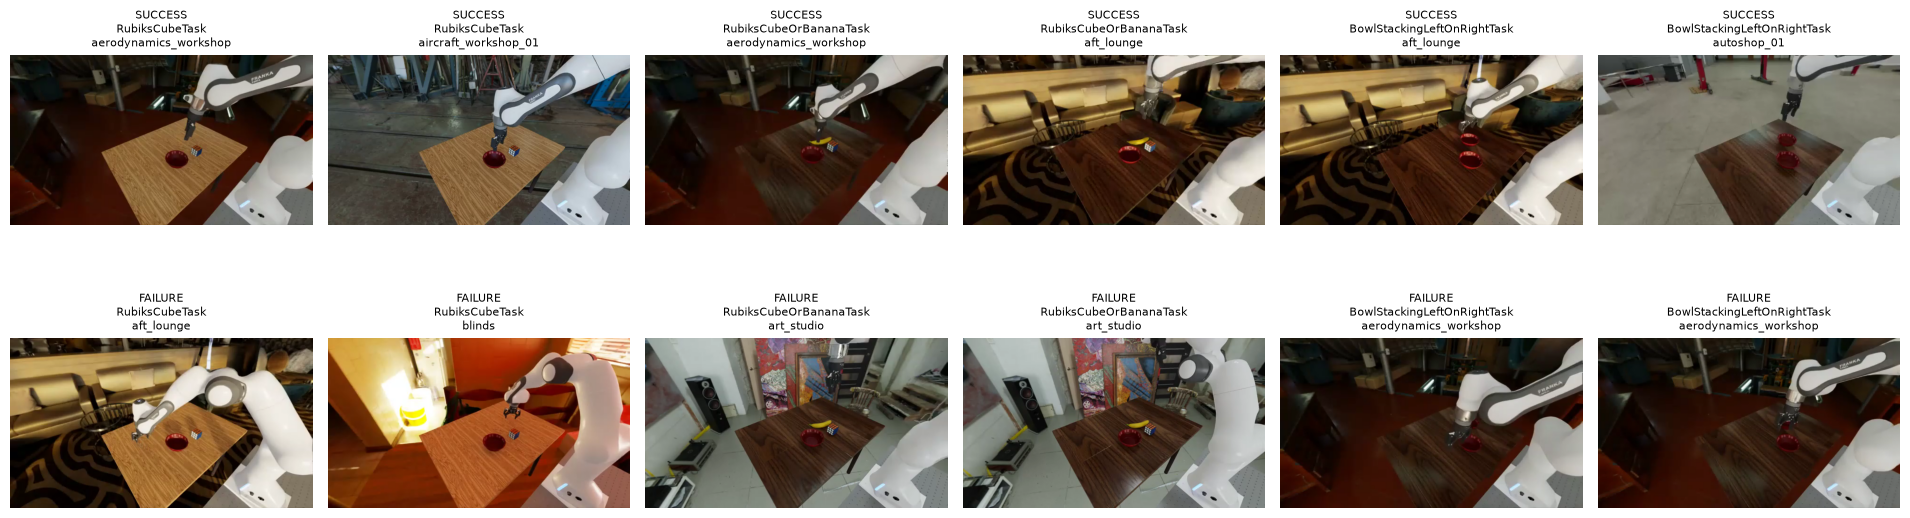

In [5]:
import av
import matplotlib.pyplot as plt

from lancedb_robotics.blob import fetch_blob
from lancedb_robotics.schema_registry import redecode_payload_blob

CAMERA_TOPIC = "/exo-left-camera"


def decode_first_camera_frame_rgb(run_id, topic):
    """Decode only the first (real, independently-decodable) message on `topic`."""
    rows = (
        lake.table("observations")
        .search()
        .where(f"run_id = '{run_id}' AND topic = '{topic}'")
        .select(["observation_id", "timestamp_ns", "schema_digest", "message_encoding"])
        .to_arrow()
        .to_pylist()
    )
    if not rows:
        return None
    rows.sort(key=lambda r: r["timestamp_ns"])
    row = dict(rows[0])
    row["payload_blob"] = fetch_blob(
        lake.table("observations"), "payload_blob", row["observation_id"], id_column="observation_id"
    )
    result = redecode_payload_blob(lake, row)
    if result.status != "decoded" or not result.blobs:
        return None
    codec_format = json.loads(result.payload_json)["format"]
    codec_name = "hevc" if codec_format == "h265" else "h264"
    ctx = av.CodecContext.create(codec_name, "r")
    decoded = ctx.decode(av.Packet(result.blobs[0]))
    return decoded[0].to_ndarray(format="rgb24") if decoded else None


successes = [m for m in episodes_meta if m["success"]]
failures = [m for m in episodes_meta if not m["success"]]
n_cols = max(len(successes), len(failures))

fig, axes = plt.subplots(2, n_cols, figsize=(3.2 * n_cols, 6.4))
for row_metas, row_axes, label in [(successes, axes[0], "SUCCESS"), (failures, axes[1], "FAILURE")]:
    for ax, meta in zip(row_axes, row_metas):
        frame = decode_first_camera_frame_rgb(meta["episode_run_id"], CAMERA_TOPIC)
        if frame is not None:
            ax.imshow(frame)
        else:
            ax.text(0.5, 0.5, "no frame", ha="center", va="center")
        ax.set_title(f"{label}\n{meta['task']}\n{meta['background']}", fontsize=8)
        ax.axis("off")
    for ax in row_axes[len(row_metas):]:
        ax.axis("off")
plt.tight_layout()
plt.show()


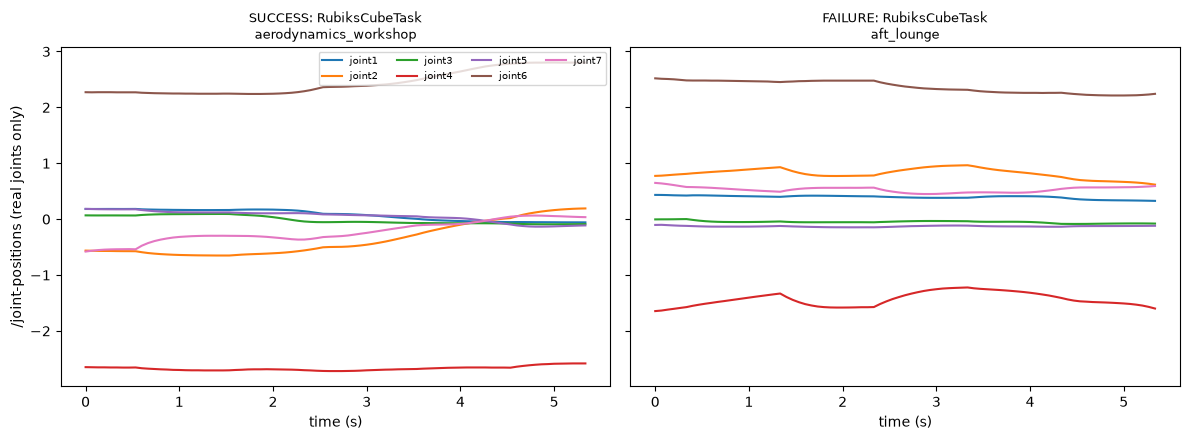

In [6]:
def load_state_trajectory(run_id, topic):
    rows = (
        lake.table("observations")
        .search()
        .where(f"run_id = '{run_id}' AND topic = '{topic}'")
        .select(["timestamp_ns", "state_vector"])
        .to_arrow()
        .to_pylist()
    )
    rows.sort(key=lambda r: r["timestamp_ns"])
    t0 = rows[0]["timestamp_ns"]
    times = [(r["timestamp_ns"] - t0) / 1e9 for r in rows]
    return times, [r["state_vector"] for r in rows]


compare_task = TASKS[0]
success_meta = next(m for m in episodes_meta if m["task"] == compare_task and m["success"])
fail_meta = next(m for m in episodes_meta if m["task"] == compare_task and not m["success"])

# Real per-dimension variance (checked against real downloaded data): dims 0-6 of
# /joint-positions are a real, moving 7-DOF arm; dims 7-12 are uniformly zero in
# every episode -- an unused/reserved slot, not a gripper signal, so only the
# real joints are plotted (component names are index-only in LAYOUTS for the
# same reason: nothing beyond "the Nth value in position" is claimed).
N_REAL_JOINTS = 7

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, meta, label in [(axes[0], success_meta, "SUCCESS"), (axes[1], fail_meta, "FAILURE")]:
    times, states = load_state_trajectory(meta["episode_run_id"], STATE_TOPIC)
    for j in range(N_REAL_JOINTS):
        ax.plot(times, [v[j] for v in states], label=f"joint{j + 1}")
    ax.set_title(f"{label}: {meta['task']}\n{meta['background']}", fontsize=9)
    ax.set_xlabel("time (s)")
axes[0].set_ylabel("/joint-positions (real joints only)")
axes[0].legend(loc="upper right", fontsize=7, ncol=4)
plt.tight_layout()
plt.show()


## 4. Real success/failure search -- structured cards + thumbnails

Real fields this time, not a proxy: task, background, the genuine `success`
label, plus the same first-frame thumbnail mechanism, so a researcher can see
a match, not just trust a label.


4 match(es) for task='Rubiks' success=False:

- RubiksCubeTask                   aft_lounge               FAILURE  "Put the cube in the bowl"
- RubiksCubeTask                   blinds                   FAILURE  "Put the cube in the bowl"
- RubiksCubeOrBananaTask           art_studio               FAILURE  "Put the cube or the banana in the bowl"
- RubiksCubeOrBananaTask           art_studio               FAILURE  "Put the cube or the banana in the bowl"


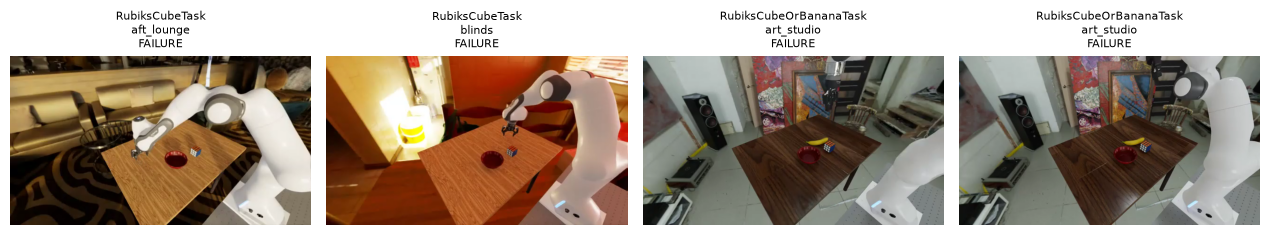

In [7]:
def show_result_cards(matches):
    if not matches:
        print("no matches")
        return
    fig, axes = plt.subplots(1, len(matches), figsize=(3.2 * len(matches), 3.6))
    axes = [axes] if len(matches) == 1 else list(axes)
    for ax, meta in zip(axes, matches):
        frame = decode_first_camera_frame_rgb(meta["episode_run_id"], CAMERA_TOPIC)
        if frame is not None:
            ax.imshow(frame)
        else:
            ax.text(0.5, 0.5, "no frame", ha="center", va="center")
        verdict = "SUCCESS" if meta["success"] else "FAILURE"
        ax.set_title(f"{meta['task']}\n{meta['background']}\n{verdict}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def search_and_show(task_keyword=None, success=None):
    matches = [
        meta
        for meta in episodes_meta
        if (task_keyword is None or task_keyword.lower() in meta["task"].lower())
        and (success is None or meta["success"] == success)
    ]
    print(f"{len(matches)} match(es) for task={task_keyword!r} success={success!r}:\n")
    for meta in matches:
        verdict = "SUCCESS" if meta["success"] else "FAILURE"
        print(f"- {meta['task']:32s} {meta['background']:24s} {verdict:8s} \"{meta['instruction']}\"")
    show_result_cards(matches)
    return matches


_ = search_and_show(task_keyword="Rubiks", success=False)


## 5. Align each episode

Every topic in a RoboLab-EgoX episode reports exactly `num_frames` messages
(confirmed on real data: state/action/camera/depth all report 81 for an
81-frame episode) -- a much simpler alignment case than ABC-130k's
heterogeneous multi-rate topics. 15 fps, tight tolerance, nearest-neighbor.


In [8]:
for meta in episodes_meta:
    view_name = f"robolab_{meta['take_name']}"
    lake.align.create_view(
        view_name,
        run_id=meta["episode_run_id"],
        rate_hz=15.0,
        streams=ALL_TOPICS,
        tolerance_ms=40.0,
        interpolation={topic: "nearest" for topic in ALL_TOPICS},
    )
    meta["alignment_name"] = view_name

print(f"{len(episodes_meta)} alignments created.")


12 alignments created.


## 6. The live LeRobot facade

One `LiveLeRobotFacade` per episode: `observation.state` is the real
13-value `/joint-positions` vector, `action` is the real 8-value `/actions`
vector. No export step -- this reads `aligned_ticks` directly.


In [9]:
mapping = CanonicalVectorMapping(
    state_streams=(STATE_TOPIC,),
    action_streams=(ACTION_TOPIC,),
)

facades = []
for meta in episodes_meta:
    facade = LiveLeRobotFacade(lake, name=meta["alignment_name"], mapping=mapping)
    facades.append(facade)
    meta["frames"] = len(facade)

for meta in episodes_meta:
    verdict = "success" if meta["success"] else "FAILURE"
    print(f"{meta['task']:32s} {meta['take_name']:48s} {verdict:8s} {meta['frames']:3d} frames")

item0 = facades[0][0]
print()
print("one item:", {k: (v if not isinstance(v, list) else f"list[{len(v)}]") for k, v in item0.items()})


RubiksCubeTask                   RubiksCubeTask_aerodynamics_workshop_sf34        success   80 frames
RubiksCubeTask                   RubiksCubeTask_aircraft_workshop_01_sf14         success   80 frames
RubiksCubeTask                   RubiksCubeTask_aft_lounge_sf50                   FAILURE   80 frames
RubiksCubeTask                   RubiksCubeTask_blinds_sf50                       FAILURE   80 frames
RubiksCubeOrBananaTask           RubiksCubeOrBananaTask_aerodynamics_workshop_sf18 success   80 frames
RubiksCubeOrBananaTask           RubiksCubeOrBananaTask_aft_lounge_sf0            success   80 frames
RubiksCubeOrBananaTask           RubiksCubeOrBananaTask_art_studio_sf0            FAILURE   80 frames
RubiksCubeOrBananaTask           RubiksCubeOrBananaTask_art_studio_sf185          FAILURE   80 frames
BowlStackingLeftOnRightTask      BowlStackingLeftOnRightTask_aft_lounge_sf48      success   80 frames
BowlStackingLeftOnRightTask      BowlStackingLeftOnRightTask_autoshop_01_sf0     

## 7. Combine episodes + a real `torch.utils.data.DataLoader`


In [10]:
torch_datasets = [to_torch_dataset(facade) for facade in facades]
combined = ConcatDataset(torch_datasets)
print(f"combined dataset: {len(combined)} frames across {len(torch_datasets)} episodes")

loader = DataLoader(combined, batch_size=8, shuffle=False)
for i, batch in enumerate(loader):
    print(
        f"batch {i}: observation.state {tuple(batch['observation.state'].shape)}"
        f" ({batch['observation.state'].dtype}), action {tuple(batch['action'].shape)}"
    )
    if i >= 2:
        break


combined dataset: 960 frames across 12 episodes
batch 0: observation.state (8, 13) (torch.float32), action (8, 8)
batch 1: observation.state (8, 13) (torch.float32), action (8, 8)
batch 2: observation.state (8, 13) (torch.float32), action (8, 8)


## 8. Curate a named, durable view over the successful episodes

Unlike ABC-130k, no proxy is needed here -- the curation criterion is the
real `success` label. `curate.py`'s workbench operates at **scenario** grain
(joined to `runs`), so each physical episode first gets exactly one
whole-episode `scenarios` row via `scenarios.create_scenario_windows`
(window wider than any real episode's ~5.4s duration).


In [11]:
from lancedb_robotics.curate import CurationScope
from lancedb_robotics.scenarios import create_scenario_windows, parse_duration_ns

scenario_report = create_scenario_windows(lake, window_ns=parse_duration_ns("1m"), include_partial=True)
print(scenario_report)

run_to_scenario = {}
for row in lake.table("scenarios").to_arrow().to_pylist():
    run_to_scenario.setdefault(row["run_id"], row["scenario_id"])
for meta in episodes_meta:
    meta["scenario_id"] = run_to_scenario[meta["episode_run_id"]]

passing_scenario_ids = tuple(meta["scenario_id"] for meta in episodes_meta if meta["success"])
scope = CurationScope(scenario_ids=passing_scenario_ids)
selection = lake.curate.workbench(scope=scope)
view = selection.save_view(
    "robolab_egox_training_ready",
    description="RoboLab-EgoX episodes with a real, ground-truth successful rollout",
    tags=("demo", "robolab-egox"),
)
print(f"saved view {view.name!r}: {view.membership_count} scenario(s), status={view.status!r}")

reopened = lake.curate.view("robolab_egox_training_ready")
assert set(reopened.scenario_ids) == set(passing_scenario_ids)
print("reopened membership:", reopened.scenario_ids)


ScenarioWindowReport(lake_uri='/var/folders/n8/6q91s9mj5r557f40145k5g240000gn/T/tmp55b8mwf7/robolab_egox.lance', transform_id='tfm-scenarios-edefdea62f4ac8f9', window_ns=60000000000, topics=(), include_partial=True, runs_considered=12, rows_added=12, rows_replaced=0, windows_by_run={'run-0615f1bb71cab85e': 1, 'run-0a35aa452dfadb60': 1, 'run-164ede3ff05cbba7': 1, 'run-52f66ae90f3fced9': 1, 'run-8ca8281dd5b586fe': 1, 'run-9a13b383210b584d': 1, 'run-a0d4f4afd3878571': 1, 'run-a16e6654712471e2': 1, 'run-a35159b7a7d945f7': 1, 'run-a7434a0e096cd445': 1, 'run-aafa76e9ac66afe1': 1, 'run-cdcff298a332871b': 1})
saved view 'robolab_egox_training_ready': 6 scenario(s), status='active'
reopened membership: ('scn-19fb077b3ead362e', 'scn-55f5cad09c7ee576', 'scn-625710e3d0f90883', 'scn-71ff51d440e622bc', 'scn-a09d6b9b29f23fa5', 'scn-c30283a7e58393bd')


## 9. A filtered `DataLoader` from the curated view -- zero copies, zero shards

Real successes only, for training -- mapped straight back to the
already-open per-episode facades from section 6. No export, no shard
directory, no duplicated data.


In [12]:
curated_scenario_ids = set(reopened.scenario_ids)
curated_run_ids = {
    meta["episode_run_id"] for meta in episodes_meta if meta["scenario_id"] in curated_scenario_ids
}

curated_datasets = [
    to_torch_dataset(facade)
    for facade, meta in zip(facades, episodes_meta)
    if meta["episode_run_id"] in curated_run_ids
]
curated_combined = ConcatDataset(curated_datasets)
print(
    f"curated dataset: {len(curated_combined)} frames across "
    f"{len(curated_datasets)}/{len(facades)} episodes -- selected via the saved "
    "CurationView (real success label), reusing the same live facades from section 6."
)

curated_loader = DataLoader(curated_combined, batch_size=8, shuffle=False)
for i, batch in enumerate(curated_loader):
    print(
        f"batch {i}: observation.state {tuple(batch['observation.state'].shape)}"
        f" ({batch['observation.state'].dtype}), action {tuple(batch['action'].shape)}"
    )
    if i >= 1:
        break


curated dataset: 480 frames across 6/12 episodes -- selected via the saved CurationView (real success label), reusing the same live facades from section 6.
batch 0: observation.state (8, 13) (torch.float32), action (8, 8)
batch 1: observation.state (8, 13) (torch.float32), action (8, 8)


## Wrap-up

What this notebook proved, on a second real, external dataset with a
genuinely different label story than ABC-130k:

- **A real cross-dataset bug, found and fixed**: RoboLab-EgoX's
  `/joint-positions` (13-length) and `/actions` (8-length) collide with
  XDOF ABC-130k's own `RobotState` schema name -- `extract.py` now
  disambiguates real producers by field shape rather than assuming a bare
  schema name is globally unique, with regression tests proving both
  datasets still type correctly.
- **A real failure label**: unlike ABC-130k, RoboLab-EgoX ships a genuine
  ground-truth `success`/`failure` per episode -- search and curation here
  use that real label directly, no data-quality proxy needed.
- **Alignment -> live facade -> real `DataLoader`**: two heterogeneous
  RobotState-shaped topics (13 state, 8 action), synchronized and served
  live, no export step.
- **Curation on a real label**: `curate.py`'s real scenario-grain workbench,
  fed the real successful-episode set, persisted as a named, durable
  `CurationView`.
- **Filtered `DataLoader` with zero copies**: the curated view maps straight
  back to the already-open per-episode facades -- no export, no shard
  directory.

**Explicitly out of scope here:** full camera playback. RoboLab-EgoX's
cameras are real H.264 Annex-B *without B-frames* (per its own docs) --
genuinely simpler than ABC-130k's H.264/H.265, but still inter-frame
dependent (P-frames), so per-frame random access still needs the GOP-aware
decode path this repo's `video.py` already has for the JPEG-per-message case
-- not attempted here. Sections 3-4 decode only the first (independently
decodable) message per camera for a thumbnail.
